In [ ]:
# !pip install -i https://test.pypi.org/simple/ machinegnostics

Looking in indexes: https://test.pypi.org/simple/


In [45]:
import pandas as pd

In [46]:
# selecting for second row
df = pd.read_excel("../data/Results_alphas.xlsx", sheet_name=1, header=1)

In [47]:
df

,Exp,FR[%],WF,Q[W],alpha,beta,Te_std[C],Tc_std[C],P[bar],Te_mean[K],Tc_mean[K],Te_std[K],Tc_std[K],T_pulse[K],TR[K/W],Perfomance_TR[%],A[m2],h[W/m2K]
0,PHP_2,60,DI water,40,0,0,0.39,1.36,0.79,355.55,303.67,273.54,274.51,353.75,1.30,-30.000000,0.005024,153.465371
1,PHP_2,60,DI water,40,30,0,0.54,1.26,0.82,357.47,304.92,273.69,274.41,0.00,1.31,-31.000000,0.005024,151.508724
2,PHP_2,60,DI water,40,60,0,0.58,2.33,0.82,352.91,305.72,273.73,275.48,352.47,1.18,-18.000000,0.005024,168.717598
3,PHP_2,60,DI water,40,90,0,0.91,7.14,0.76,352.17,312.32,274.06,280.29,322.31,1.00,0.000000,0.005024,199.793813
4,PHP_2,60,DI water,60,0,0,0.53,4.49,1.00,362.97,308.62,273.68,277.64,352.85,0.91,-21.333333,0.005024,219.736433
5,PHP_2,60,DI water,60,30,0,1.43,3.37,1.00,363.01,308.38,274.58,276.52,351.05,0.91,-21.333333,0.005024,218.610199
6,PHP_2,60,DI water,60,60,0,0.82,8.78,1.00,356.03,321.27,273.97,281.93,342.29,0.58,22.666667,0.005024,343.575235
7,PHP_2,60,DI water,60,90,0,0.43,1.32,1.00,351.21,306.40,273.58,274.47,0.00,0.75,0.000000,0.005024,266.518080
8,PHP_2,60,DI water,80,0,0,0.51,1.22,0.76,363.97,303.38,273.66,274.37,327.27,0.76,-52.000000,0.005024,262.808498
9,PHP_2,60,DI water,80,30,0,1.54,13.74,1.01,356.89,318.05,274.69,286.89,335.47,0.49,2.000000,0.005024,409.978550


In [60]:
alpha = 0
Q = 120
cols = ["Q[W]", "alpha", "TR[K/W]", "P[bar]", "Perfomance_TR[%]	"]

df_ = df[(df['alpha']==alpha)][['alpha', 'Q[W]', 'TR[K/W]']]
df_.reset_index(inplace=True, drop=True)
df_

,alpha,Q[W],TR[K/W]
0,0,40,1.30
1,0,60,0.91
2,0,80,0.76
3,0,100,0.80
4,0,120,0.44


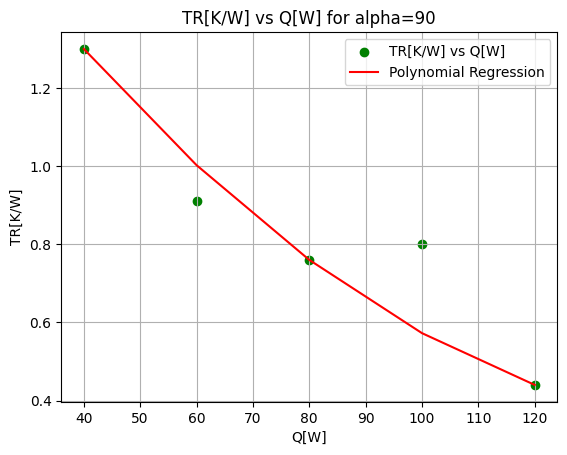

In [66]:
# step 1 - x and y values
# x = df_['Q[W]']
# y = df_['TR[K/W]']

X = df_[['Q[W]']]
y = df_['TR[K/W]']

# step 2 - import model
from machinegnostics.models.regression import PolynomialRegressor
model = PolynomialRegressor(degree=2)

# step 3 - fit the model
model.fit(X, y)

# step 4 - predict
y_pred = model.predict(X)
from machinegnostics.metrics import robr2
robr2_score = robr2(y, y_pred)

# step 5 - plot the results
import matplotlib.pyplot as plt
plt.scatter(df_['Q[W]'], df_['TR[K/W]'], color='g', label='TR[K/W] vs Q[W]')
plt.plot(df_['Q[W]'], y_pred, color='r', label='Polynomial Regression')
plt.xlabel('Q[W]')
plt.ylabel('TR[K/W]')
plt.title(f'TR[K/W] vs Q[W] for alpha={alpha}')
plt.legend()
plt.grid()
plt.show()  



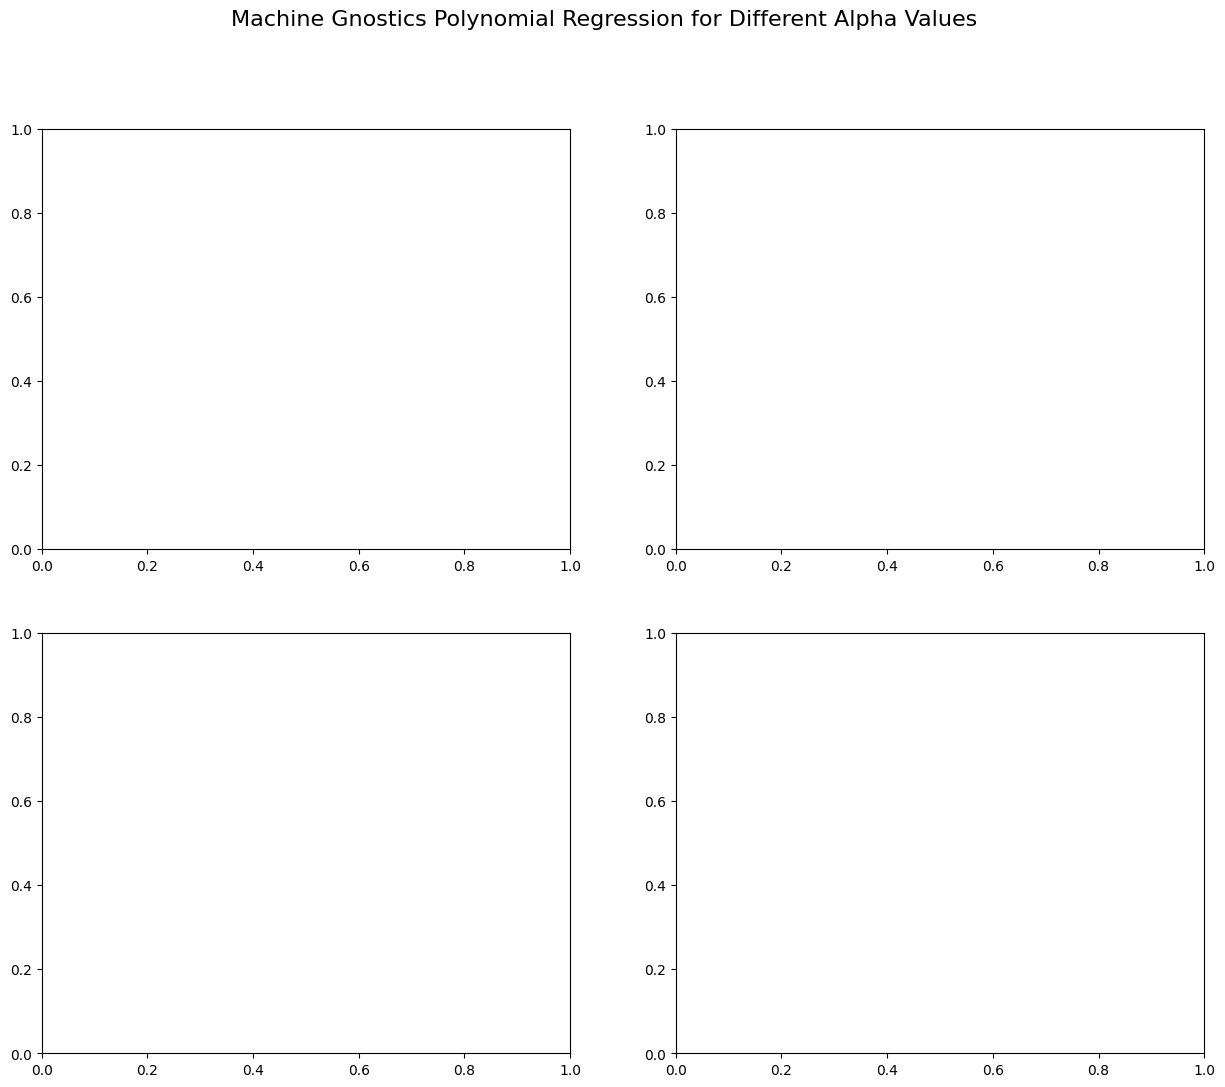

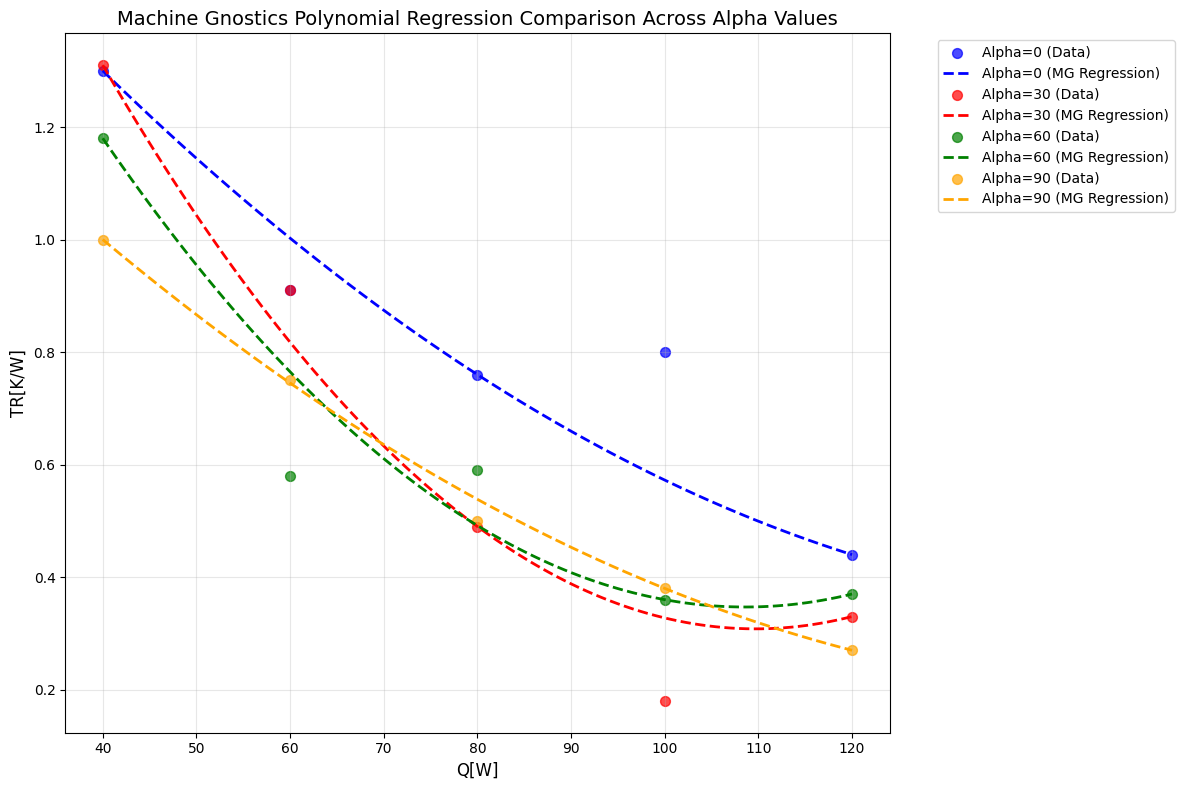

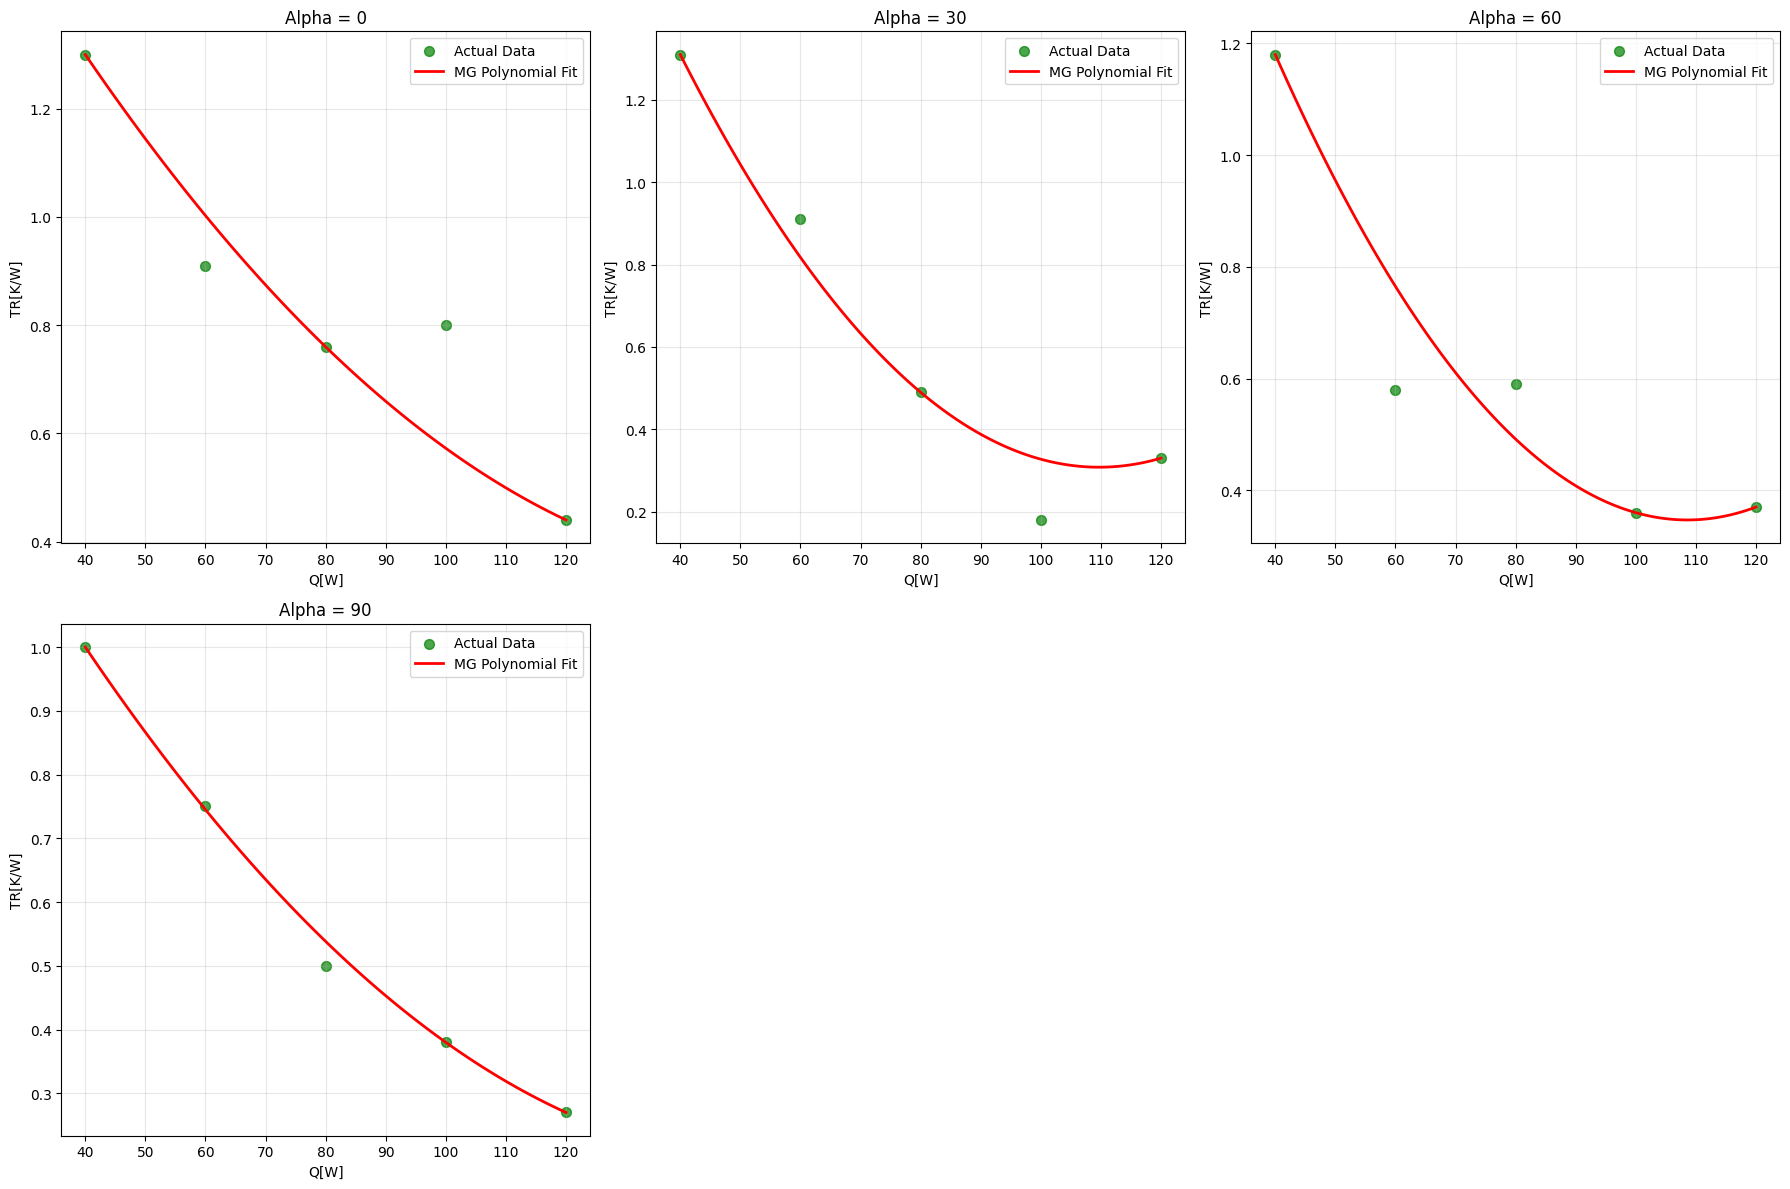

Model Performance Summary:
Alpha 0: R² Score = 0.8431, Data Points = 5
Alpha 30: R² Score = 0.9644, Data Points = 5
Alpha 60: R² Score = 0.9016, Data Points = 5
Alpha 90: R² Score = 0.9957, Data Points = 5


In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from machinegnostics.models.regression import PolynomialRegressor
import numpy as np

# Load data
df = pd.read_excel("../data/Results_alphas.xlsx", sheet_name=1, header=1)

# Get unique alpha values
alpha_values = df['alpha'].unique()

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Machine Gnostics Polynomial Regression for Different Alpha Values', fontsize=16)

# Colors for different alphas
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

# Plot for comparison of all alphas
plt.figure(figsize=(12, 8))

for i, alpha in enumerate(alpha_values):
    # Filter data for current alpha
    df_alpha = df[df['alpha'] == alpha][['alpha', 'Q[W]', 'TR[K/W]']].reset_index(drop=True)
    
    if len(df_alpha) == 0:
        continue
    
    # Prepare data
    X = df_alpha[['Q[W]']]
    y = df_alpha['TR[K/W]']
    
    # Train Machine Gnostics model
    model = PolynomialRegressor(degree=2)
    model.fit(X, y)
    
    # Generate smooth curve for prediction
    Q_range = np.linspace(X.min().values[0], X.max().values[0], 100)
    X_smooth = pd.DataFrame({'Q[W]': Q_range})
    y_pred_smooth = model.predict(X_smooth)
    
    # Plot original data points
    plt.scatter(df_alpha['Q[W]'], df_alpha['TR[K/W]'], 
               color=colors[i % len(colors)], alpha=0.7, s=50,
               label=f'Alpha={alpha} (Data)')
    
    # Plot regression line
    plt.plot(Q_range, y_pred_smooth, 
            color=colors[i % len(colors)], linewidth=2, linestyle='--',
            label=f'Alpha={alpha} (MG Regression)')

plt.xlabel('Q[W]', fontsize=12)
plt.ylabel('TR[K/W]', fontsize=12)
plt.title('Machine Gnostics Polynomial Regression Comparison Across Alpha Values', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Individual plots for each alpha
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, alpha in enumerate(alpha_values[:6]):  # Limit to 6 plots
    df_alpha = df[df['alpha'] == alpha][['alpha', 'Q[W]', 'TR[K/W]']].reset_index(drop=True)
    
    if len(df_alpha) == 0:
        continue
    
    # Prepare data
    X = df_alpha[['Q[W]']]
    y = df_alpha['TR[K/W]']
    
    # Train model
    model = PolynomialRegressor(degree=2)
    model.fit(X, y)
    
    # Generate predictions
    Q_range = np.linspace(X.min().values[0], X.max().values[0], 100)
    X_smooth = pd.DataFrame({'Q[W]': Q_range})
    y_pred_smooth = model.predict(X_smooth)
    
    # Plot on subplot
    axes[i].scatter(df_alpha['Q[W]'], df_alpha['TR[K/W]'], 
                   color='green', alpha=0.7, s=50, label='Actual Data')
    axes[i].plot(Q_range, y_pred_smooth, 
                color='red', linewidth=2, label='MG Polynomial Fit')
    axes[i].set_xlabel('Q[W]')
    axes[i].set_ylabel('TR[K/W]')
    axes[i].set_title(f'Alpha = {alpha}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Hide empty subplots
for j in range(len(alpha_values), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Print model performance metrics for each alpha
print("Model Performance Summary:")
print("=" * 50)

for alpha in alpha_values:
    df_alpha = df[df['alpha'] == alpha][['alpha', 'Q[W]', 'TR[K/W]']].reset_index(drop=True)
    
    if len(df_alpha) == 0:
        continue
        
    X = df_alpha[['Q[W]']]
    y = df_alpha['TR[K/W]']
    
    model = PolynomialRegressor(degree=2)
    model.fit(X, y)
    y_pred = model.predict(X)
    
    # Calculate R² score
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2_score = 1 - (ss_res / ss_tot)
    
    print(f"Alpha {alpha}: R² Score = {r2_score:.4f}, Data Points = {len(df_alpha)}")

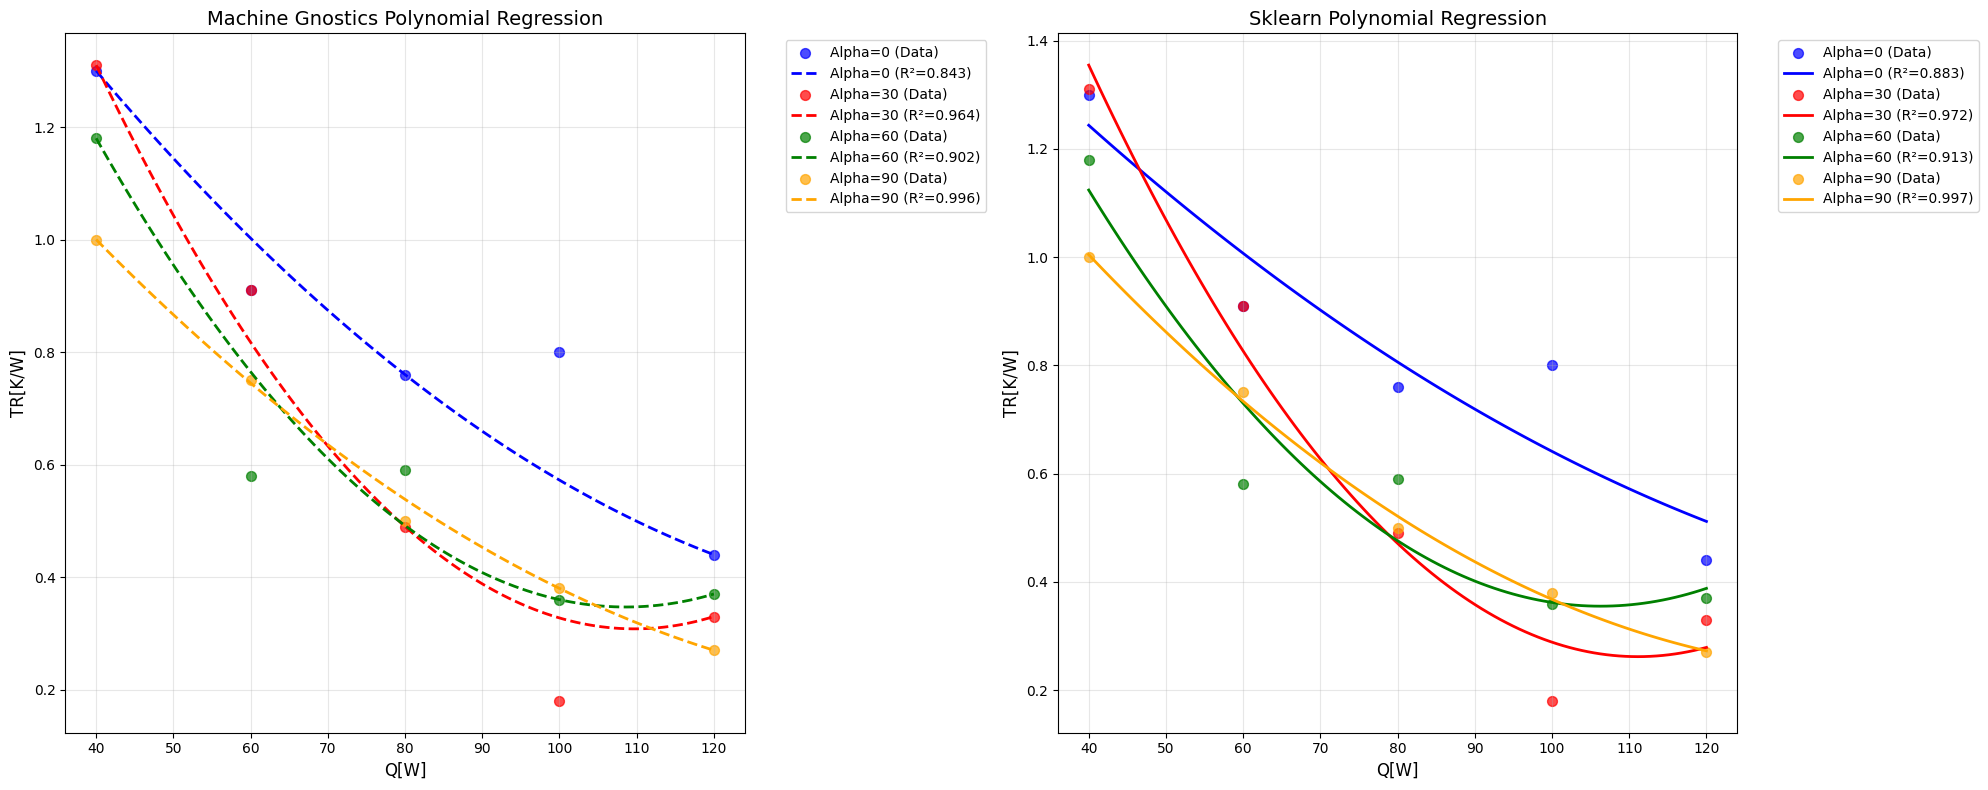

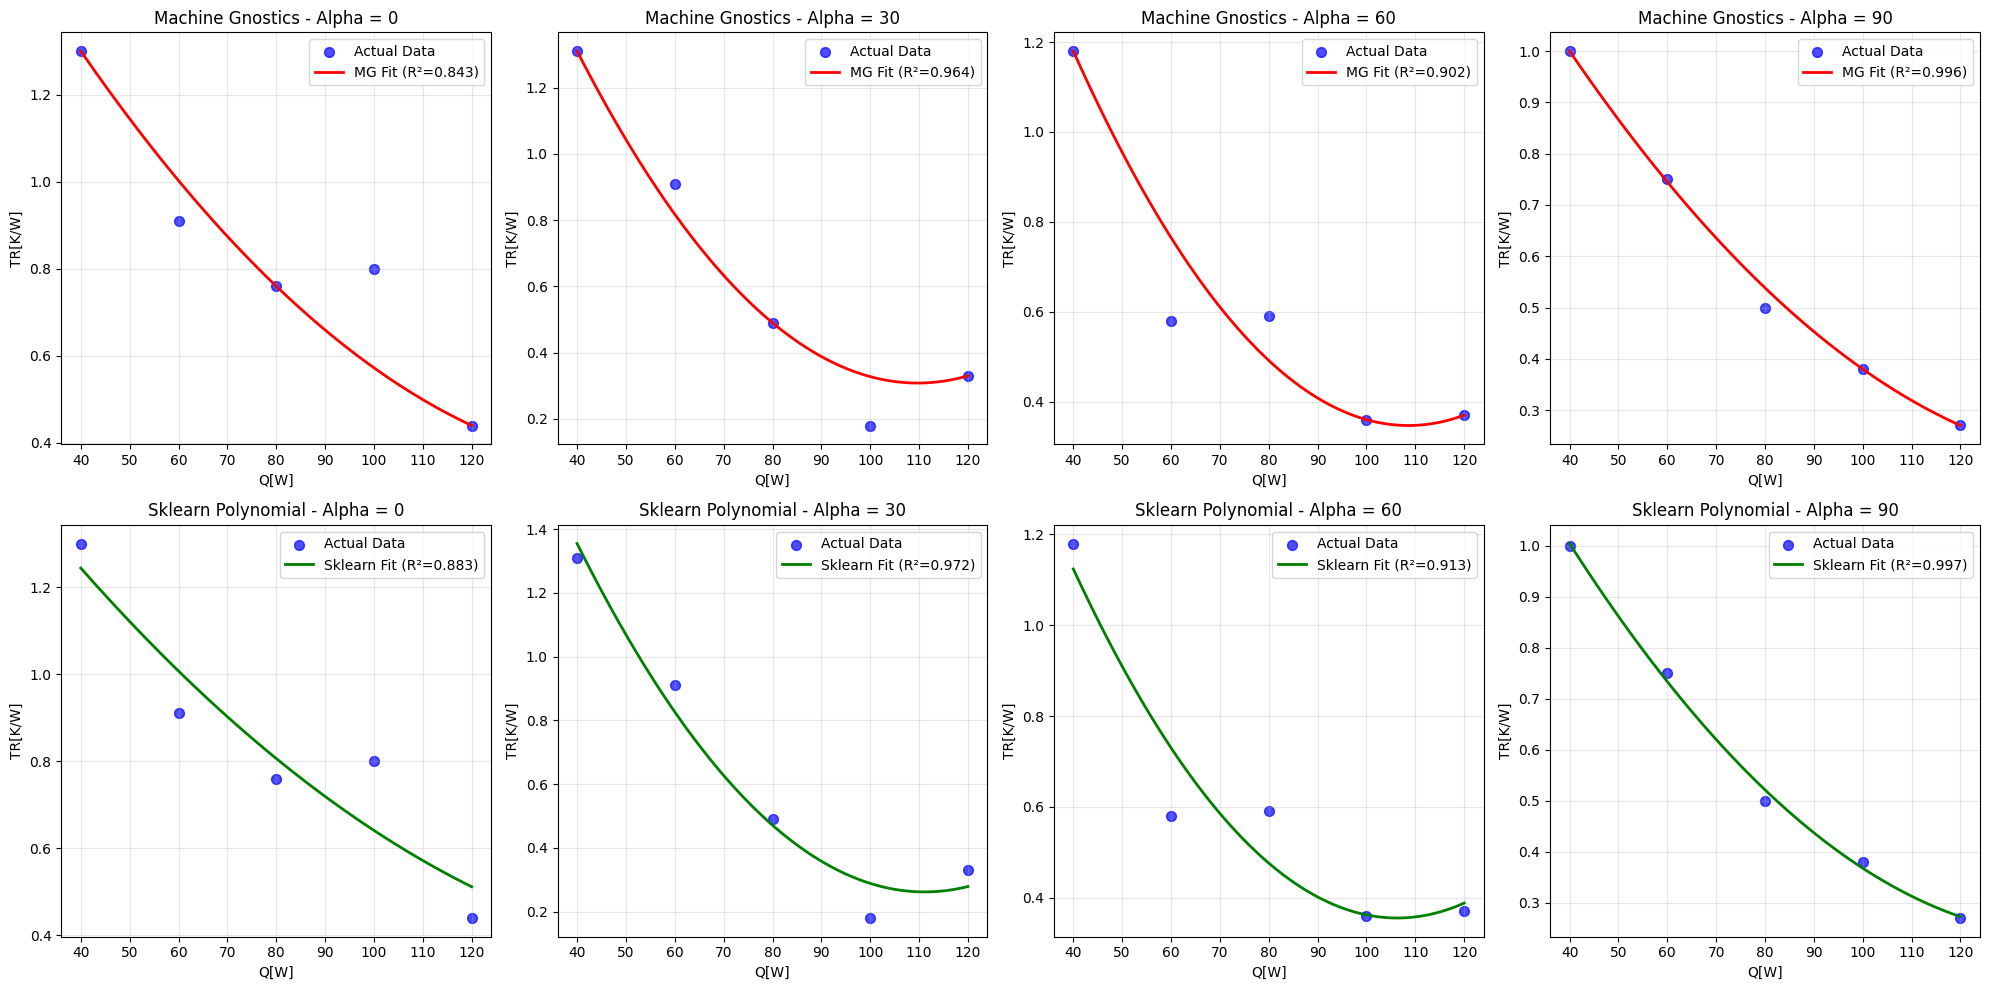

Detailed Performance Comparison:
Alpha    MG R²        Sklearn R²   Difference   Data Points 
--------------------------------------------------------------------------------
0.0      0.8431       0.8826       -0.0395      5.0         
30.0     0.9644       0.9721       -0.0077      5.0         
60.0     0.9016       0.9127       -0.0111      5.0         
90.0     0.9957       0.9974       -0.0017      5.0         

Summary Statistics:
--------------------------------------------------
Average MG R²: 0.9262
Average Sklearn R²: 0.9412
Average Difference: -0.0150
Standard Deviation of Difference: 0.0168


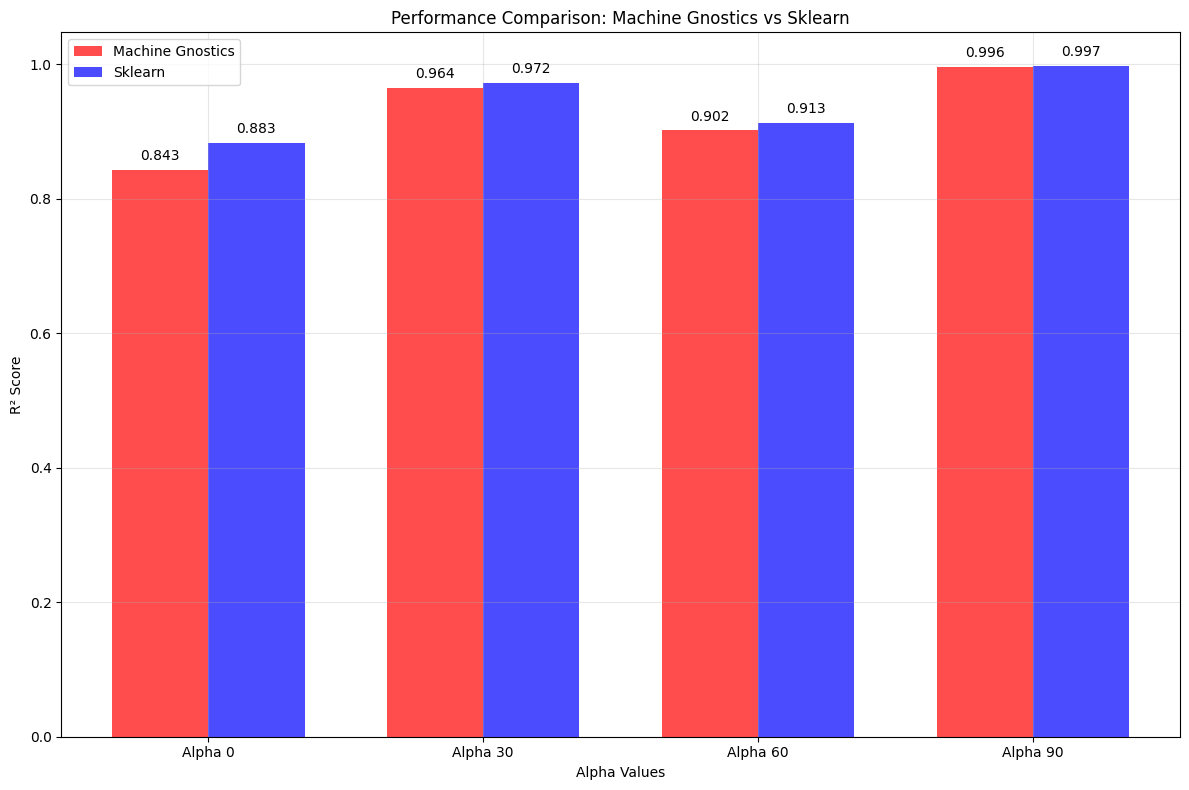

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from machinegnostics.models.regression import PolynomialRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import numpy as np

# Load data
df = pd.read_excel("../data/Results_alphas.xlsx", sheet_name=1, header=1)

# Get unique alpha values
alpha_values = df['alpha'].unique()

# Colors for different alphas
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

# Create comparison plot: Machine Gnostics vs Sklearn
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Store performance metrics
performance_comparison = []

for i, alpha in enumerate(alpha_values):
    # Filter data for current alpha
    df_alpha = df[df['alpha'] == alpha][['alpha', 'Q[W]', 'TR[K/W]']].reset_index(drop=True)
    
    if len(df_alpha) == 0:
        continue
    
    # Prepare data
    X = df_alpha[['Q[W]']]
    y = df_alpha['TR[K/W]']
    X_sklearn = df_alpha['Q[W]'].values.reshape(-1, 1)
    
    # Train Machine Gnostics model
    mg_model = PolynomialRegressor(degree=2)
    mg_model.fit(X, y)
    
    # Train Sklearn model
    sklearn_model = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
    ])
    sklearn_model.fit(X_sklearn, y)
    
    # Generate smooth curve for prediction
    Q_range = np.linspace(X.min().values[0], X.max().values[0], 100)
    X_smooth_mg = pd.DataFrame({'Q[W]': Q_range})
    X_smooth_sklearn = Q_range.reshape(-1, 1)
    
    # Get predictions
    mg_pred_smooth = mg_model.predict(X_smooth_mg)
    sklearn_pred_smooth = sklearn_model.predict(X_smooth_sklearn)
    
    mg_pred = mg_model.predict(X)
    sklearn_pred = sklearn_model.predict(X_sklearn)
    
    # Calculate R² scores
    mg_r2 = r2_score(y, mg_pred)
    sklearn_r2 = sklearn_model.score(X_sklearn, y)
    
    # Store performance metrics
    performance_comparison.append({
        'Alpha': alpha,
        'MG_R2': mg_r2,
        'Sklearn_R2': sklearn_r2,
        'Data_Points': len(df_alpha)
    })
    
    # Plot Machine Gnostics results
    ax1.scatter(df_alpha['Q[W]'], df_alpha['TR[K/W]'], 
               color=colors[i % len(colors)], alpha=0.7, s=50,
               label=f'Alpha={alpha} (Data)')
    ax1.plot(Q_range, mg_pred_smooth, 
            color=colors[i % len(colors)], linewidth=2, linestyle='--',
            label=f'Alpha={alpha} (R²={mg_r2:.3f})')
    
    # Plot Sklearn results
    ax2.scatter(df_alpha['Q[W]'], df_alpha['TR[K/W]'], 
               color=colors[i % len(colors)], alpha=0.7, s=50,
               label=f'Alpha={alpha} (Data)')
    ax2.plot(Q_range, sklearn_pred_smooth, 
            color=colors[i % len(colors)], linewidth=2, linestyle='-',
            label=f'Alpha={alpha} (R²={sklearn_r2:.3f})')

# Configure plots
ax1.set_xlabel('Q[W]', fontsize=12)
ax1.set_ylabel('TR[K/W]', fontsize=12)
ax1.set_title('Machine Gnostics Polynomial Regression', fontsize=14)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Q[W]', fontsize=12)
ax2.set_ylabel('TR[K/W]', fontsize=12)
ax2.set_title('Sklearn Polynomial Regression', fontsize=14)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed comparison with subplots
fig, axes = plt.subplots(2, len(alpha_values), figsize=(5*len(alpha_values), 10))
if len(alpha_values) == 1:
    axes = axes.reshape(-1, 1)

for i, alpha in enumerate(alpha_values):
    df_alpha = df[df['alpha'] == alpha][['alpha', 'Q[W]', 'TR[K/W]']].reset_index(drop=True)
    
    if len(df_alpha) == 0:
        continue
    
    # Prepare data
    X = df_alpha[['Q[W]']]
    y = df_alpha['TR[K/W]']
    X_sklearn = df_alpha['Q[W]'].values.reshape(-1, 1)
    
    # Train models
    mg_model = PolynomialRegressor(degree=2)
    mg_model.fit(X, y)
    
    sklearn_model = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
    ])
    sklearn_model.fit(X_sklearn, y)
    
    # Generate predictions
    Q_range = np.linspace(X.min().values[0], X.max().values[0], 100)
    X_smooth_mg = pd.DataFrame({'Q[W]': Q_range})
    X_smooth_sklearn = Q_range.reshape(-1, 1)
    
    mg_pred_smooth = mg_model.predict(X_smooth_mg)
    sklearn_pred_smooth = sklearn_model.predict(X_smooth_sklearn)
    
    mg_pred = mg_model.predict(X)
    sklearn_pred = sklearn_model.predict(X_sklearn)
    
    # Calculate R² scores
    mg_r2 = r2_score(y, mg_pred)
    sklearn_r2 = sklearn_model.score(X_sklearn, y)
    
    # Plot Machine Gnostics
    axes[0, i].scatter(df_alpha['Q[W]'], df_alpha['TR[K/W]'], 
                      color='blue', alpha=0.7, s=50, label='Actual Data')
    axes[0, i].plot(Q_range, mg_pred_smooth, 
                   color='red', linewidth=2, label=f'MG Fit (R²={mg_r2:.3f})')
    axes[0, i].set_xlabel('Q[W]')
    axes[0, i].set_ylabel('TR[K/W]')
    axes[0, i].set_title(f'Machine Gnostics - Alpha = {alpha}')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)
    
    # Plot Sklearn
    axes[1, i].scatter(df_alpha['Q[W]'], df_alpha['TR[K/W]'], 
                      color='blue', alpha=0.7, s=50, label='Actual Data')
    axes[1, i].plot(Q_range, sklearn_pred_smooth, 
                   color='green', linewidth=2, label=f'Sklearn Fit (R²={sklearn_r2:.3f})')
    axes[1, i].set_xlabel('Q[W]')
    axes[1, i].set_ylabel('TR[K/W]')
    axes[1, i].set_title(f'Sklearn Polynomial - Alpha = {alpha}')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Performance comparison table
performance_df = pd.DataFrame(performance_comparison)
print("Detailed Performance Comparison:")
print("=" * 80)
print(f"{'Alpha':<8} {'MG R²':<12} {'Sklearn R²':<12} {'Difference':<12} {'Data Points':<12}")
print("-" * 80)

for _, row in performance_df.iterrows():
    diff = row['MG_R2'] - row['Sklearn_R2']
    print(f"{row['Alpha']:<8} {row['MG_R2']:<12.4f} {row['Sklearn_R2']:<12.4f} {diff:<12.4f} {row['Data_Points']:<12}")

# Summary statistics
print("\nSummary Statistics:")
print("-" * 50)
print(f"Average MG R²: {performance_df['MG_R2'].mean():.4f}")
print(f"Average Sklearn R²: {performance_df['Sklearn_R2'].mean():.4f}")
print(f"Average Difference: {(performance_df['MG_R2'] - performance_df['Sklearn_R2']).mean():.4f}")
print(f"Standard Deviation of Difference: {(performance_df['MG_R2'] - performance_df['Sklearn_R2']).std():.4f}")

# Performance comparison visualization
plt.figure(figsize=(12, 8))
x_pos = np.arange(len(alpha_values))
width = 0.35

plt.bar(x_pos - width/2, performance_df['MG_R2'], width, 
        label='Machine Gnostics', color='red', alpha=0.7)
plt.bar(x_pos + width/2, performance_df['Sklearn_R2'], width, 
        label='Sklearn', color='blue', alpha=0.7)

plt.xlabel('Alpha Values')
plt.ylabel('R² Score')
plt.title('Performance Comparison: Machine Gnostics vs Sklearn')
plt.xticks(x_pos, [f'Alpha {alpha}' for alpha in alpha_values])
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels on bars
for i, (mg_score, sk_score) in enumerate(zip(performance_df['MG_R2'], performance_df['Sklearn_R2'])):
    plt.text(i - width/2, mg_score + 0.01, f'{mg_score:.3f}', ha='center', va='bottom')
    plt.text(i + width/2, sk_score + 0.01, f'{sk_score:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

/var/folders/qf/2jw75py95_q8c1t5jmt77sx80000gn/T/ipykernel_18454/2433363550.py:331: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


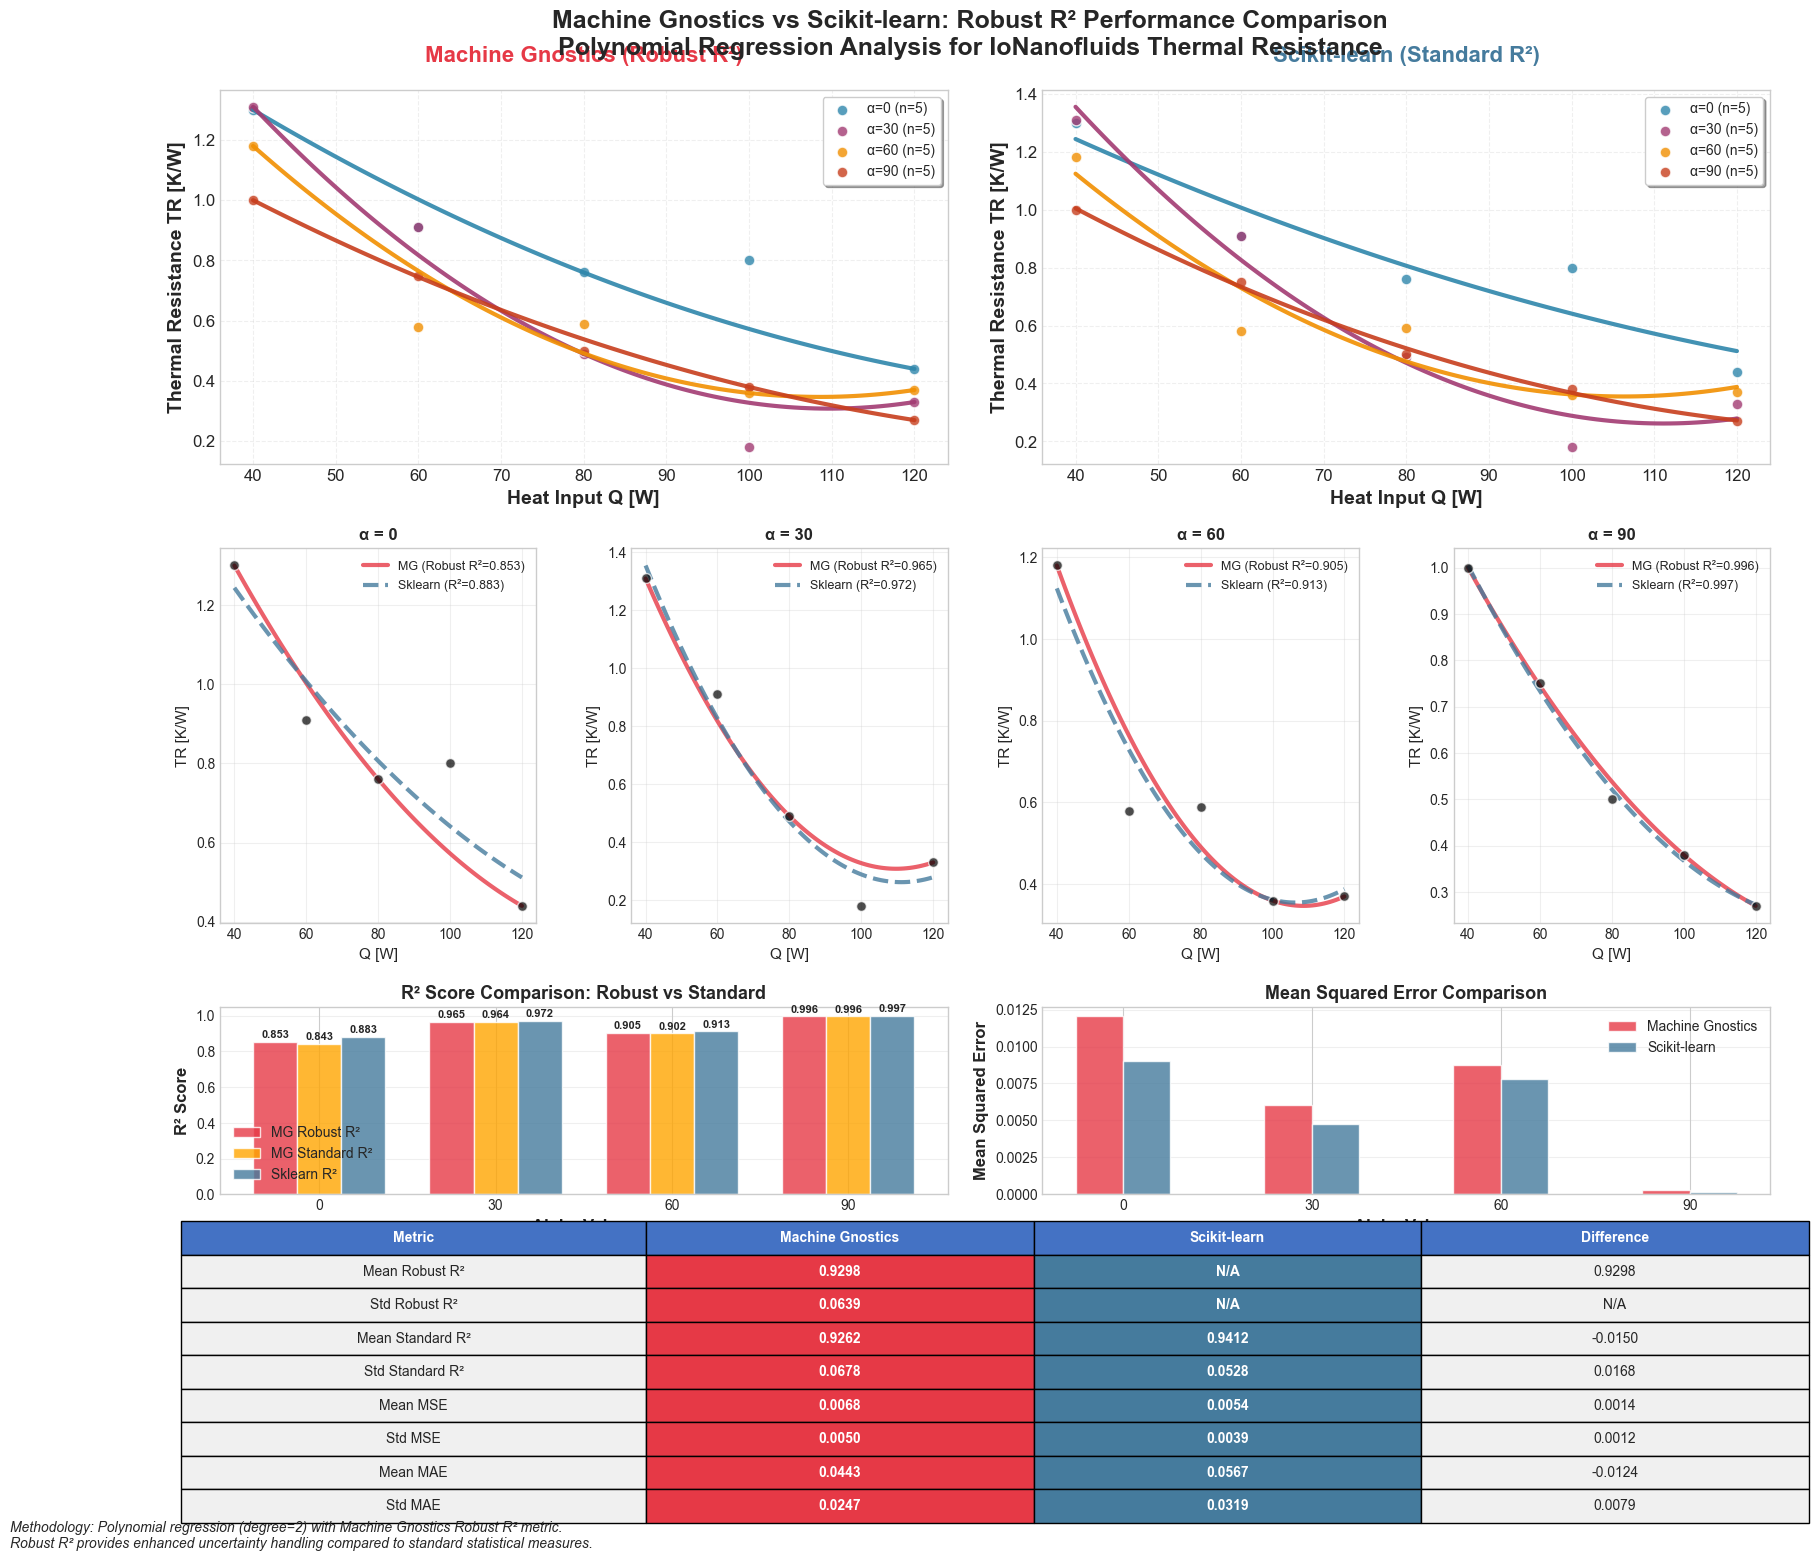


COMPREHENSIVE PERFORMANCE COMPARISON REPORT - WITH ROBUST R²

Alpha    MG Robust R² MG Std R²  SK R²      MG MSE       SK MSE       MG MAE     SK MAE     Points  
------------------------------------------------------------------------------------------------------------------------
0.0      0.8526       0.8431     0.8826     0.012062     0.009025     0.0640     0.0861     5.0     
30.0     0.9651       0.9644     0.9721     0.006062     0.004746     0.0480     0.0614     5.0     
60.0     0.9050       0.9016     0.9127     0.008779     0.007792     0.0567     0.0680     5.0     
90.0     0.9963       0.9957     0.9974     0.000299     0.000181     0.0087     0.0114     5.0     

ROBUST R² STATISTICAL SUMMARY

Robust R² Analysis (Machine Gnostics only):
Mean: 0.9298
Std:  0.0639
Min:  0.8526
Max:  0.9963

Standard R² Comparison:
Machine Gnostics - Mean: 0.9262, Std: 0.0678
Scikit-learn     - Mean: 0.9412, Std: 0.0528
Difference:        Mean: -0.014997

Robust vs Standard R² (Machine G

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from machinegnostics.models.regression import PolynomialRegressor
from machinegnostics.metrics import robr2
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import seaborn as sns

# Set style for publication quality
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load data
df = pd.read_excel("../data/Results_alphas.xlsx", sheet_name=1, header=1)
alpha_values = df['alpha'].unique()

# Enhanced color palette for publication
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#592E83', '#0F4C75']
mg_color = '#E63946'  # Red for Machine Gnostics
sklearn_color = '#457B9D'  # Blue for Sklearn

# =============================================================================
# MAIN COMPARISON FIGURE - Publication Quality with Robust R²
# =============================================================================

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 4, height_ratios=[2, 2, 1, 1], width_ratios=[1, 1, 1, 1], 
                      hspace=0.3, wspace=0.3)

# Store performance metrics
performance_comparison = []

# =============================================================================
# SECTION 1: Side-by-side Comparison Plots
# =============================================================================

ax_mg = fig.add_subplot(gs[0, :2])
ax_sklearn = fig.add_subplot(gs[0, 2:])

for i, alpha in enumerate(alpha_values):
    df_alpha = df[df['alpha'] == alpha][['alpha', 'Q[W]', 'TR[K/W]']].reset_index(drop=True)
    
    if len(df_alpha) == 0:
        continue
    
    # Prepare data
    X = df_alpha[['Q[W]']]
    y = df_alpha['TR[K/W]']
    X_sklearn = df_alpha['Q[W]'].values.reshape(-1, 1)
    
    # Train models
    mg_model = PolynomialRegressor(degree=2)
    mg_model.fit(X, y)
    
    sklearn_model = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
    ])
    sklearn_model.fit(X_sklearn, y)
    
    # Generate smooth predictions
    Q_range = np.linspace(X.min().values[0], X.max().values[0], 100)
    X_smooth_mg = pd.DataFrame({'Q[W]': Q_range})
    X_smooth_sklearn = Q_range.reshape(-1, 1)
    
    mg_pred_smooth = mg_model.predict(X_smooth_mg)
    sklearn_pred_smooth = sklearn_model.predict(X_smooth_sklearn)
    
    mg_pred = mg_model.predict(X)
    sklearn_pred = sklearn_model.predict(X_sklearn)
    
    # Calculate comprehensive metrics including robust R²
    mg_robust_r2 = robr2(y, mg_pred)  # Machine Gnostics robust R²
    sklearn_r2 = r2_score(y, sklearn_pred)  # Standard R²
    mg_standard_r2 = r2_score(y, mg_pred)  # Standard R² for comparison
    
    mg_mse = mean_squared_error(y, mg_pred)
    sklearn_mse = mean_squared_error(y, sklearn_pred)
    mg_mae = mean_absolute_error(y, mg_pred)
    sklearn_mae = mean_absolute_error(y, sklearn_pred)
    
    # Store metrics
    performance_comparison.append({
        'Alpha': alpha,
        'MG_Robust_R2': mg_robust_r2,
        'MG_Standard_R2': mg_standard_r2,
        'Sklearn_R2': sklearn_r2,
        'MG_MSE': mg_mse, 
        'Sklearn_MSE': sklearn_mse,
        'MG_MAE': mg_mae, 
        'Sklearn_MAE': sklearn_mae,
        'Data_Points': len(df_alpha)
    })
    
    # Plot Machine Gnostics with robust R²
    ax_mg.scatter(df_alpha['Q[W]'], df_alpha['TR[K/W]'], 
                 color=colors[i % len(colors)], alpha=0.8, s=60, 
                 edgecolors='white', linewidth=1,
                 label=f'α={alpha} (n={len(df_alpha)})')
    ax_mg.plot(Q_range, mg_pred_smooth, 
              color=colors[i % len(colors)], linewidth=3, linestyle='-',
              alpha=0.9)
    
    # Plot Sklearn
    ax_sklearn.scatter(df_alpha['Q[W]'], df_alpha['TR[K/W]'], 
                      color=colors[i % len(colors)], alpha=0.8, s=60,
                      edgecolors='white', linewidth=1,
                      label=f'α={alpha} (n={len(df_alpha)})')
    ax_sklearn.plot(Q_range, sklearn_pred_smooth, 
                   color=colors[i % len(colors)], linewidth=3, linestyle='-',
                   alpha=0.9)

# Configure main comparison plots
for ax, title, color in [(ax_mg, 'Machine Gnostics (Robust R²)', mg_color), 
                        (ax_sklearn, 'Scikit-learn (Standard R²)', sklearn_color)]:
    ax.set_xlabel('Heat Input Q [W]', fontsize=14, fontweight='bold')
    ax.set_ylabel('Thermal Resistance TR [K/W]', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', color=color, pad=20)
    ax.legend(loc='upper right', fontsize=10, frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(labelsize=12)

# =============================================================================
# SECTION 2: Individual Detailed Comparisons with Robust R²
# =============================================================================

for idx, alpha in enumerate(alpha_values[:4]):  # Show first 4 alphas
    row = 1
    col = idx
    
    ax = fig.add_subplot(gs[row, col])
    
    df_alpha = df[df['alpha'] == alpha][['alpha', 'Q[W]', 'TR[K/W]']].reset_index(drop=True)
    
    if len(df_alpha) == 0:
        continue
    
    # Prepare data
    X = df_alpha[['Q[W]']]
    y = df_alpha['TR[K/W]']
    X_sklearn = df_alpha['Q[W]'].values.reshape(-1, 1)
    
    # Train models
    mg_model = PolynomialRegressor(degree=2)
    mg_model.fit(X, y)
    
    sklearn_model = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
    ])
    sklearn_model.fit(X_sklearn, y)
    
    # Predictions
    Q_range = np.linspace(X.min().values[0], X.max().values[0], 100)
    X_smooth_mg = pd.DataFrame({'Q[W]': Q_range})
    X_smooth_sklearn = Q_range.reshape(-1, 1)
    
    mg_pred_smooth = mg_model.predict(X_smooth_mg)
    sklearn_pred_smooth = sklearn_model.predict(X_smooth_sklearn)
    
    mg_pred = mg_model.predict(X)
    sklearn_pred = sklearn_model.predict(X_sklearn)
    
    # Calculate metrics with robust R²
    mg_robust_r2 = robr2(y, mg_pred)
    sklearn_r2 = r2_score(y, sklearn_pred)
    
    # Plot data and fits
    ax.scatter(df_alpha['Q[W]'], df_alpha['TR[K/W]'], 
              color='black', alpha=0.7, s=50, zorder=3, edgecolors='white')
    ax.plot(Q_range, mg_pred_smooth, color=mg_color, linewidth=3, 
           label=f'MG (Robust R²={mg_robust_r2:.3f})', alpha=0.8)
    ax.plot(Q_range, sklearn_pred_smooth, color=sklearn_color, linewidth=3, 
           linestyle='--', label=f'Sklearn (R²={sklearn_r2:.3f})', alpha=0.8)
    
    ax.set_xlabel('Q [W]', fontsize=11)
    ax.set_ylabel('TR [K/W]', fontsize=11)
    ax.set_title(f'α = {alpha}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# =============================================================================
# SECTION 3: Performance Metrics Comparison with Robust R²
# =============================================================================

performance_df = pd.DataFrame(performance_comparison)

# Robust R² vs Standard R² Comparison
ax_r2 = fig.add_subplot(gs[2, :2])
x_pos = np.arange(len(alpha_values))
width = 0.25

bars1 = ax_r2.bar(x_pos - width, performance_df['MG_Robust_R2'], width, 
                  label='MG Robust R²', color=mg_color, alpha=0.8,
                  edgecolor='white', linewidth=1)
bars2 = ax_r2.bar(x_pos, performance_df['MG_Standard_R2'], width, 
                  label='MG Standard R²', color='orange', alpha=0.8,
                  edgecolor='white', linewidth=1)
bars3 = ax_r2.bar(x_pos + width, performance_df['Sklearn_R2'], width, 
                  label='Sklearn R²', color=sklearn_color, alpha=0.8,
                  edgecolor='white', linewidth=1)

ax_r2.set_xlabel('Alpha Values', fontsize=12, fontweight='bold')
ax_r2.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax_r2.set_title('R² Score Comparison: Robust vs Standard', fontsize=13, fontweight='bold')
ax_r2.set_xticks(x_pos)
ax_r2.set_xticklabels([f'{alpha}' for alpha in alpha_values])
ax_r2.legend(fontsize=10)
ax_r2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (robust_score, standard_score, sk_score) in enumerate(zip(
    performance_df['MG_Robust_R2'], performance_df['MG_Standard_R2'], performance_df['Sklearn_R2'])):
    ax_r2.text(i - width, robust_score + 0.01, f'{robust_score:.3f}', 
              ha='center', va='bottom', fontweight='bold', fontsize=8)
    ax_r2.text(i, standard_score + 0.01, f'{standard_score:.3f}', 
              ha='center', va='bottom', fontweight='bold', fontsize=8)
    ax_r2.text(i + width, sk_score + 0.01, f'{sk_score:.3f}', 
              ha='center', va='bottom', fontweight='bold', fontsize=8)

# MSE Comparison
ax_mse = fig.add_subplot(gs[2, 2:])
bars4 = ax_mse.bar(x_pos - width/2, performance_df['MG_MSE'], width, 
                   label='Machine Gnostics', color=mg_color, alpha=0.8,
                   edgecolor='white', linewidth=1)
bars5 = ax_mse.bar(x_pos + width/2, performance_df['Sklearn_MSE'], width, 
                   label='Scikit-learn', color=sklearn_color, alpha=0.8,
                   edgecolor='white', linewidth=1)

ax_mse.set_xlabel('Alpha Values', fontsize=12, fontweight='bold')
ax_mse.set_ylabel('Mean Squared Error', fontsize=12, fontweight='bold')
ax_mse.set_title('Mean Squared Error Comparison', fontsize=13, fontweight='bold')
ax_mse.set_xticks(x_pos)
ax_mse.set_xticklabels([f'{alpha}' for alpha in alpha_values])
ax_mse.legend(fontsize=10)
ax_mse.grid(True, alpha=0.3, axis='y')

# =============================================================================
# SECTION 4: Enhanced Statistical Summary Table with Robust R²
# =============================================================================

ax_table = fig.add_subplot(gs[3, :])
ax_table.axis('off')

# Calculate summary statistics including robust R²
summary_stats = {
    'Metric': ['Mean Robust R²', 'Std Robust R²', 'Mean Standard R²', 'Std Standard R²', 
               'Mean MSE', 'Std MSE', 'Mean MAE', 'Std MAE'],
    'Machine Gnostics': [
        f"{performance_df['MG_Robust_R2'].mean():.4f}",
        f"{performance_df['MG_Robust_R2'].std():.4f}",
        f"{performance_df['MG_Standard_R2'].mean():.4f}",
        f"{performance_df['MG_Standard_R2'].std():.4f}",
        f"{performance_df['MG_MSE'].mean():.4f}",
        f"{performance_df['MG_MSE'].std():.4f}",
        f"{performance_df['MG_MAE'].mean():.4f}",
        f"{performance_df['MG_MAE'].std():.4f}"
    ],
    'Scikit-learn': [
        'N/A',  # No robust R² for sklearn
        'N/A',
        f"{performance_df['Sklearn_R2'].mean():.4f}",
        f"{performance_df['Sklearn_R2'].std():.4f}",
        f"{performance_df['Sklearn_MSE'].mean():.4f}",
        f"{performance_df['Sklearn_MSE'].std():.4f}",
        f"{performance_df['Sklearn_MAE'].mean():.4f}",
        f"{performance_df['Sklearn_MAE'].std():.4f}"
    ],
    'Difference (MG - Sklearn)': [
        f"{performance_df['MG_Robust_R2'].mean():.4f}",  # Robust vs N/A
        'N/A',
        f"{(performance_df['MG_Standard_R2'] - performance_df['Sklearn_R2']).mean():.4f}",
        f"{(performance_df['MG_Standard_R2'] - performance_df['Sklearn_R2']).std():.4f}",
        f"{(performance_df['MG_MSE'] - performance_df['Sklearn_MSE']).mean():.4f}",
        f"{(performance_df['MG_MSE'] - performance_df['Sklearn_MSE']).std():.4f}",
        f"{(performance_df['MG_MAE'] - performance_df['Sklearn_MAE']).mean():.4f}",
        f"{(performance_df['MG_MAE'] - performance_df['Sklearn_MAE']).std():.4f}"
    ]
}

table_data = []
for i in range(len(summary_stats['Metric'])):
    table_data.append([
        summary_stats['Metric'][i],
        summary_stats['Machine Gnostics'][i],
        summary_stats['Scikit-learn'][i],
        summary_stats['Difference (MG - Sklearn)'][i]
    ])

table = ax_table.table(cellText=table_data,
                      colLabels=['Metric', 'Machine Gnostics', 'Scikit-learn', 'Difference'],
                      cellLoc='center',
                      loc='center',
                      colWidths=[0.3, 0.25, 0.25, 0.25])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# Style the table
for i in range(len(summary_stats['Metric']) + 1):
    for j in range(4):
        cell = table[(i, j)]
        if i == 0:  # Header row
            cell.set_facecolor('#4472C4')
            cell.set_text_props(weight='bold', color='white')
        else:
            if j == 1:  # Machine Gnostics column
                cell.set_facecolor(mg_color)
                cell.set_text_props(color='white', weight='bold')
            elif j == 2:  # Scikit-learn column
                cell.set_facecolor(sklearn_color)
                cell.set_text_props(color='white', weight='bold')
            else:
                cell.set_facecolor('#F0F0F0')

# Main title
fig.suptitle('Machine Gnostics vs Scikit-learn: Robust R² Performance Comparison\n' +
             'Polynomial Regression Analysis for IoNanofluids Thermal Resistance',
             fontsize=18, fontweight='bold', y=0.98)

# Add methodology note
fig.text(0.02, 0.02, 
         'Methodology: Polynomial regression (degree=2) with Machine Gnostics Robust R² metric.\n' +
         'Robust R² provides enhanced uncertainty handling compared to standard statistical measures.',
         fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.subplots_adjust(top=0.93, bottom=0.07)
plt.show()

# =============================================================================
# DETAILED PERFORMANCE REPORT with Robust R²
# =============================================================================

print("\n" + "="*120)
print("COMPREHENSIVE PERFORMANCE COMPARISON REPORT - WITH ROBUST R²")
print("="*120)

print(f"\n{'Alpha':<8} {'MG Robust R²':<12} {'MG Std R²':<10} {'SK R²':<10} {'MG MSE':<12} {'SK MSE':<12} {'MG MAE':<10} {'SK MAE':<10} {'Points':<8}")
print("-" * 120)

for _, row in performance_df.iterrows():
    print(f"{row['Alpha']:<8} {row['MG_Robust_R2']:<12.4f} {row['MG_Standard_R2']:<10.4f} {row['Sklearn_R2']:<10.4f} "
          f"{row['MG_MSE']:<12.6f} {row['Sklearn_MSE']:<12.6f} "
          f"{row['MG_MAE']:<10.4f} {row['Sklearn_MAE']:<10.4f} {row['Data_Points']:<8}")

print("\n" + "="*120)
print("ROBUST R² STATISTICAL SUMMARY")
print("="*120)

print(f"\nRobust R² Analysis (Machine Gnostics only):")
print(f"Mean: {performance_df['MG_Robust_R2'].mean():.4f}")
print(f"Std:  {performance_df['MG_Robust_R2'].std():.4f}")
print(f"Min:  {performance_df['MG_Robust_R2'].min():.4f}")
print(f"Max:  {performance_df['MG_Robust_R2'].max():.4f}")

print(f"\nStandard R² Comparison:")
print(f"Machine Gnostics - Mean: {performance_df['MG_Standard_R2'].mean():.4f}, Std: {performance_df['MG_Standard_R2'].std():.4f}")
print(f"Scikit-learn     - Mean: {performance_df['Sklearn_R2'].mean():.4f}, Std: {performance_df['Sklearn_R2'].std():.4f}")
print(f"Difference:        Mean: {(performance_df['MG_Standard_R2'] - performance_df['Sklearn_R2']).mean():.6f}")

print(f"\nRobust vs Standard R² (Machine Gnostics):")
print(f"Mean Difference: {(performance_df['MG_Robust_R2'] - performance_df['MG_Standard_R2']).mean():.6f}")
print(f"Std Difference:  {(performance_df['MG_Robust_R2'] - performance_df['MG_Standard_R2']).std():.6f}")